# **Data Exploration**
The dataset has been cleaned properly and now resides within an easily accessible CSV file. Now is the time to explore the data through summary statistic, **statistical methods**, and **data plotting**.

**Step 1:** Import necessary libraries
- **pandas** for data handling
- **ADD ADDITIONAL LIBRARIES HERE** as well as a short explanation for their use

In [30]:
import pandas as pd

from scipy.stats import f_oneway ## For ANOVA test
from scipy.stats import tukey_hsd ## Post-hoc test for ANOVA

import matplotlib.pyplot as plt
import seaborn as sns

**Step 2.1:** Perform data exploration using a unique statistical method (see rubric).

**Step 3.1:** Perform data exploration using a unique statistical method (see rubric).

**Step 4.1:** Perform data exploration using hypothesis testing (see rubric).

In [27]:
#Null Hypothesis: Average temperature across continents are the same.
#Alternative Hypothesis: Average temperature across continents are not the same.

hypo_df = pd.read_csv('weather.csv')

hypo_df['latitude_bands'] = pd.cut(hypo_df['latitude'], bins=[-90, -30, 30, 90], labels=['Southern', 'Mid', 'Northern'], include_lowest=True)

hypo_df['total_precipitation_mm'] = hypo_df['total_percipitation'] * 1000
rainy_days_df = hypo_df[hypo_df['total_precipitation_mm'] > 0]
# rainy_days_df.groupby('latitude_bands')['total_precipitation_mm'].describe()

south = rainy_days_df[rainy_days_df['latitude_bands'] == 'Southern']['total_precipitation_mm']
mid = rainy_days_df[rainy_days_df['latitude_bands'] == 'Mid']['total_precipitation_mm']
north = rainy_days_df[rainy_days_df['latitude_bands'] == 'Northern']['total_precipitation_mm']


f_statistic, p_value = f_oneway(south, mid, north)

print(f"P-value: {p_value}")

P-value: 7.142553035676119e-11


In [28]:
result = tukey_hsd(south, mid, north)
print(result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.062     0.000    -0.083    -0.040
 (0 - 2)     -0.044     0.000    -0.066    -0.022
 (1 - 0)      0.062     0.000     0.040     0.083
 (1 - 2)      0.018     0.076    -0.001     0.037
 (2 - 0)      0.044     0.000     0.022     0.066
 (2 - 1)     -0.018     0.076    -0.037     0.001



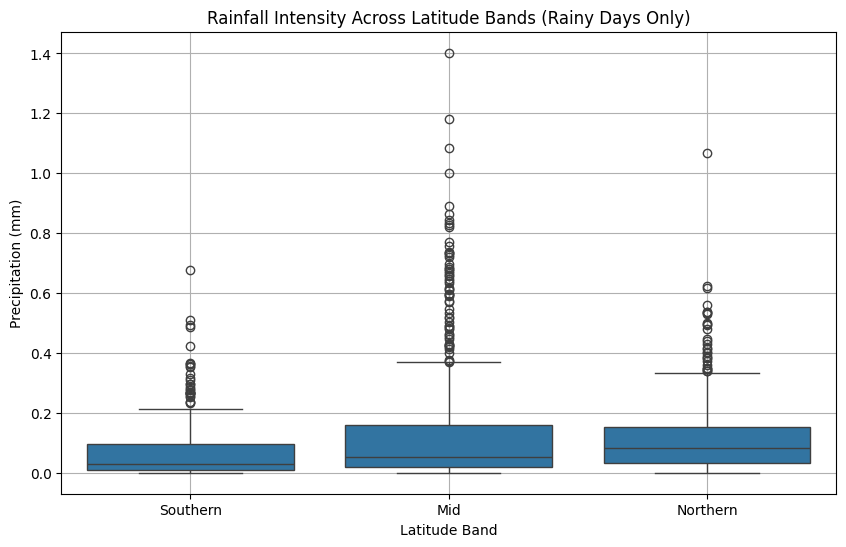

In [37]:
plt.figure(figsize=(10,6))
sns.boxplot(data=rainy_days_df, x='latitude_bands', y='total_precipitation_mm')

plt.title('Rainfall Intensity Across Latitude Bands (Rainy Days Only)')
plt.xlabel('Latitude Band')
plt.ylabel('Precipitation (mm)')
plt.grid(True)

plt.show()